# Classification and Regression

Here, we consider two csv's: 'mergedcustomers.csv' and 'predict_home_value.csv' 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn import model_selection, decomposition, preprocessing
from sklearn import linear_model, tree, ensemble

In [2]:
# Reading customer data
customer_data = pd.read_csv("mergedcustomers.csv")
customer_data = customer_data.drop(['ID'], axis=1)
customer_data

print(customer_data.columns)

Index(['CHURNRISK', 'GENDER', 'STATUS', 'CHILDREN', 'ESTINCOME', 'HOMEOWNER',
       'AGE', 'TOTALDOLLARVALUETRADED', 'TOTALUNITSTRADED',
       'LARGESTSINGLETRANSACTION', 'SMALLESTSINGLETRANSACTION',
       'PERCENTCHANGECALCULATION', 'DAYSSINCELASTLOGIN', 'DAYSSINCELASTTRADE',
       'NETREALIZEDGAINS_YTD', 'NETREALIZEDLOSSES_YTD'],
      dtype='str')


## Classification
### Decision Trees
Here, is the barest of all classification models.

In [3]:
# Let's take all last nine columns as all inputs
feature_cols = customer_data.columns[-9:] 
target_col = "CHURNRISK"

features = customer_data.loc[:, feature_cols]
target = customer_data.loc[:, target_col]

X_train, X_test, y_train, y_test = model_selection.train_test_split(features, target, train_size = 0.8, random_state = 0)

In [4]:
# Initialize DecisionTreeClassifier and fit the model to the training data
model = tree.DecisionTreeClassifier()
model.fit(X_train, y_train)

# Using the fitted model, predict the classification of the galaxies that
# are part of the test set (X_test)
y_pred = model.predict(X_test)

pred_actual_df = pd.DataFrame([y_pred, y_test]).T
pred_actual_df.columns = ["Predicted", "Actual"]
pred_actual_df

,Predicted,Actual
0,Medium,High
1,High,High
2,High,High
3,High,High
4,High,High
...,...,...
409,Low,Low
410,Medium,Medium
411,Low,Low
412,Medium,Medium


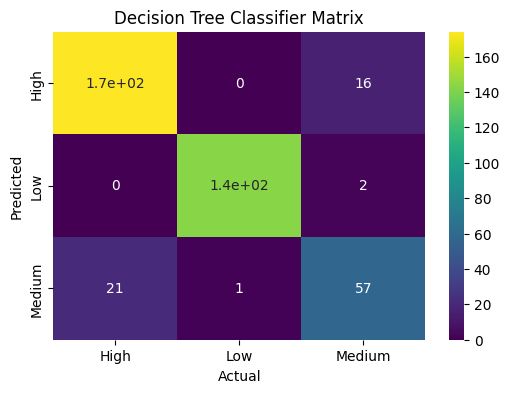

In [10]:
# We can visualize the performance of the classification by producing
# the confusion matrix. 

conf_matrix = pd.crosstab(pred_actual_df["Predicted"], pred_actual_df["Actual"])
# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot = True, cmap = "viridis")
plt.title("Decision Tree Classifier Matrix")
plt.savefig("Decision Tree Classifier.pdf")
plt.show()

### Perceptrons
Here, we look at how perceptrons work.

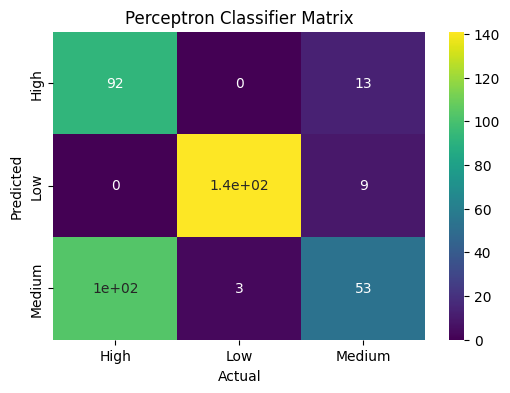

In [49]:
# Initialize DecisionTreeClassifier and fit the model to the training data
perceptron = linear_model.Perceptron()
perceptron.fit(X_train, y_train)

# Using the fitted model, predict the classification of the galaxies that
# are part of the test set (X_test)
y_pred = perceptron.predict(X_test)

pred_actual_df = pd.DataFrame([y_pred, y_test]).T
pred_actual_df.columns = ["Predicted", "Actual"]
perc_matrix = pd.crosstab(pred_actual_df["Predicted"], pred_actual_df["Actual"])
# Code above is also confusion matrix but for perceptrons

plt.figure(figsize=(6, 4))
sns.heatmap(perc_matrix, annot = True, cmap = "viridis")
plt.title("Perceptron Classifier Matrix")
plt.savefig("PerceptronClass.pdf")
plt.show()

Perceptrons actually performed better here. We now try if we reduce the feature parameters.

### Perceptron with Reduced Features

Since we're talking about churn rates in investments. What if we merely talk about estimated income, total dollar value traded, total units traded, days since last trade, net realized gains, net realized losses.

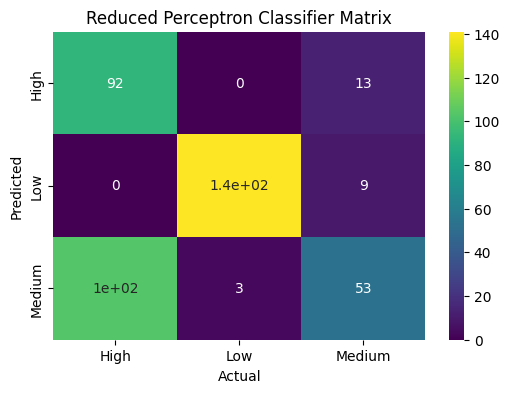

In [17]:
features2 = customer_data[["ESTINCOME", "TOTALDOLLARVALUETRADED", "TOTALUNITSTRADED", "DAYSSINCELASTTRADE",
                      "NETREALIZEDGAINS_YTD", "NETREALIZEDLOSSES_YTD"]]
target = customer_data["CHURNRISK"]

# target_col is still the same so we don't re-define it
X_train, X_test, y_train, y_test = model_selection.train_test_split(features2, target, train_size = 0.8, random_state = 0)

perceptron.fit(X_train, y_train)
y_pred = perceptron.predict(X_test)
pred_actual_df = pd.DataFrame([y_pred, y_test]).T
pred_actual_df.columns = ["Predicted", "Actual"]
conf_matrix = pd.crosstab(pred_actual_df["Predicted"], pred_actual_df["Actual"])

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot = True, cmap = "viridis")
plt.title("Reduced Perceptron Classifier Matrix")
plt.savefig("Perceptron-Reduced.pdf")
plt.show()

## Linear Regression
Here we'll be considering housing data and we aim to predict housing prices by linear and polynomial regression through different models. We'll not change number of features and just change the models.
### Pre-processing
This method is based on ordinary least squares

In [18]:
from sklearn import linear_model
from sklearn import kernel_ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,mean_squared_error, r2_score
from sklearn import preprocessing

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_graphviz

In [19]:
house_data = pd.read_csv("predict_home_value.csv")

#Get overview of data types in the DF
print(f"Size: {len(house_data)}\n{house_data.dtypes}")
house_data.sample(5) #take 5 entries from the dataset

Size: 1460
ID              int64
LOTAREA         int64
BLDGTYPE          str
HOUSESTYLE        str
OVERALLCOND     int64
YEARBUILT       int64
ROOFSTYLE         str
EXTERCOND         str
FOUNDATION        str
BSMTCOND          str
HEATING           str
HEATINGQC         str
CENTRALAIR        str
ELECTRICAL        str
FULLBATH        int64
HALFBATH        int64
BEDROOMABVGR    int64
KITCHENABVGR    int64
KITCHENQUAL       str
TOTRMSABVGRD    int64
FIREPLACES      int64
FIREPLACEQU       str
GARAGETYPE        str
GARAGEFINISH      str
GARAGECARS      int64
GARAGECOND        str
POOLAREA        int64
POOLQC            str
FENCE             str
MOSOLD          int64
YRSOLD          int64
SALEPRICE       int64
dtype: object


,ID,LOTAREA,BLDGTYPE,HOUSESTYLE,OVERALLCOND,YEARBUILT,ROOFSTYLE,EXTERCOND,FOUNDATION,BSMTCOND,...,GARAGETYPE,GARAGEFINISH,GARAGECARS,GARAGECOND,POOLAREA,POOLQC,FENCE,MOSOLD,YRSOLD,SALEPRICE
557,558,11040,1Fam,1.5Fin,6,1920,Gable,TA,CBlock,TA,...,CarPort,Unf,1,TA,0,NaN,NaN,9,2006,108000
1288,1289,5664,TwnhsE,1Story,5,2000,Gable,TA,PConc,TA,...,Attchd,Fin,2,TA,0,NaN,NaN,10,2009,278000
1292,1293,6600,1Fam,2Story,4,1892,Gable,TA,Stone,TA,...,Attchd,RFn,1,TA,0,NaN,NaN,12,2009,107500
915,916,2001,Twnhs,2Story,5,1970,Gable,TA,CBlock,TA,...,Attchd,Unf,1,TA,0,NaN,NaN,1,2007,75000
756,757,10769,1Fam,2Story,5,2007,Gable,TA,PConc,TA,...,Attchd,RFn,2,TA,0,NaN,NaN,4,2009,212000


We skipped assessing missing entries since it was already done in DeepNote. But in other datasets, this is a **MUST**

In [20]:
#Filter data based on condition (only include complete entries)
subset_cols = house_data.columns[~house_data.isna().any()] #All columns with no NA data
house_data_clean = house_data.loc[:, subset_cols]
house_data_clean = house_data_clean.sort_values(by = "YEARBUILT")

We test across different regressors and show a bonus for different pair of features
### Huber Regression
A regression model based on ordinary least squares.

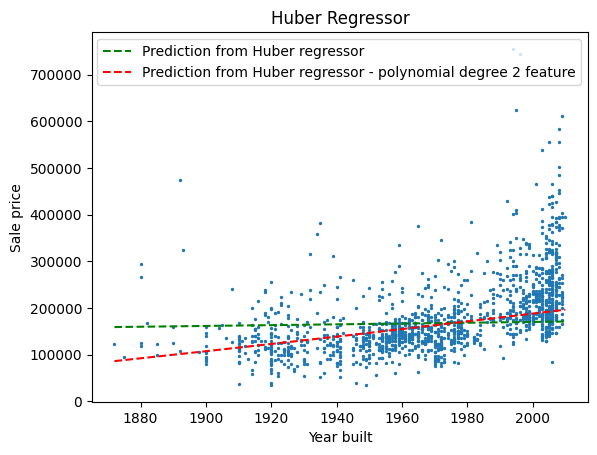

In [48]:
from sklearn.preprocessing import PolynomialFeatures

polynomial_features = PolynomialFeatures(degree = 2)

years = house_data_clean["YEARBUILT"].values.reshape(-1,1)
sale_price = house_data_clean["SALEPRICE"].values # 1D already

polynomial_features = PolynomialFeatures(degree = 2)

years = house_data_clean["YEARBUILT"].values.reshape(-1,1)
sale_price = house_data_clean["SALEPRICE"].values

year_poly = polynomial_features.fit_transform(years)

poly_model = linear_model.HuberRegressor().fit(year_poly, sale_price)
predicted_poly = poly_model.predict(year_poly)

plt.scatter(house_data_clean["YEARBUILT"], house_data_clean["SALEPRICE"], s = 2)
plt.xlabel("Year built")
plt.ylabel("Sale price")

plt.title("Huber Regressor")
plt.plot(years.reshape(-1,1), predicted_price, color = 'g', ls = '--', label = "Prediction from Huber regressor")
plt.plot(years.reshape(-1,1), predicted_poly, color = 'r', ls = '--', label = "Prediction from Huber regressor - polynomial degree 2 feature")
plt.legend()
plt.savefig("HuberRegressor.pdf")

In [22]:
huber.coef_, huber.intercept_

(array([85.45958115]), np.float64(-1055.800085914533))

### Random Forest Regressor
Here, we consider Random Forest

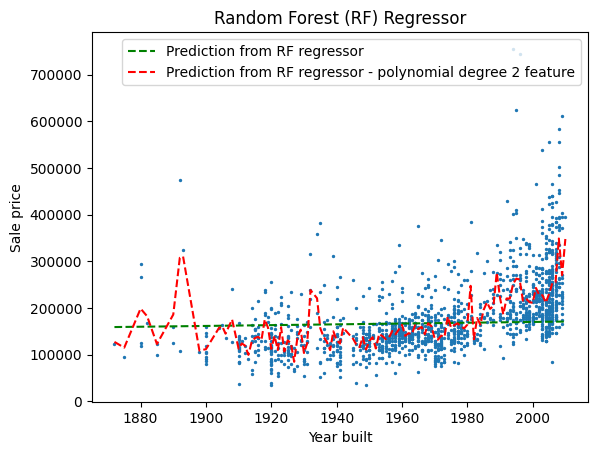

In [32]:
from sklearn.preprocessing import PolynomialFeatures

polynomial_features = PolynomialFeatures(degree = 2)

years = house_data_clean["YEARBUILT"].values.reshape(-1,1)
sale_price = house_data_clean["SALEPRICE"].values # 1D already

polynomial_features = PolynomialFeatures(degree = 2)

years = house_data_clean["YEARBUILT"].values.reshape(-1,1)
sale_price = house_data_clean["SALEPRICE"].values

year_poly = polynomial_features.fit_transform(years)

poly_model = ensemble.RandomForestRegressor().fit(year_poly, sale_price)
predicted_poly = poly_model.predict(year_poly)

plt.scatter(house_data_clean["YEARBUILT"], house_data_clean["SALEPRICE"], s = 2)
plt.xlabel("Year built")
plt.ylabel("Sale price")

plt.title("Random Forest (RF) Regressor")
plt.plot(years.reshape(-1,1), predicted_price, color = 'g', ls = '--', label = "Prediction from RF regressor")
plt.plot(years.reshape(-1,1), predicted_poly, color = 'r', ls = '--', label = "Prediction from RF regressor - polynomial degree 2 feature")
plt.legend()
plt.savefig("RandomForestRegressor.pdf")

### Boost Regressor
Random Forest is noisy, what if we do boost, does it not overshoot?

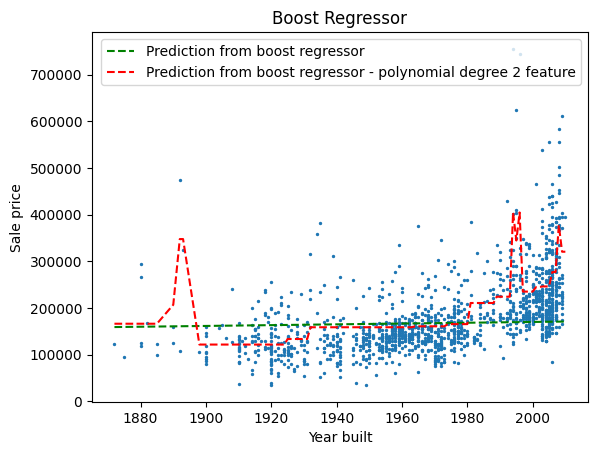

In [35]:
polynomial_features = PolynomialFeatures(degree = 2)

years = house_data_clean["YEARBUILT"].values.reshape(-1,1)
sale_price = house_data_clean["SALEPRICE"].values # 1D already

polynomial_features = PolynomialFeatures(degree = 2)

years = house_data_clean["YEARBUILT"].values.reshape(-1,1)
sale_price = house_data_clean["SALEPRICE"].values

year_poly = polynomial_features.fit_transform(years)

poly_model = ensemble.AdaBoostRegressor().fit(year_poly, sale_price)
predicted_poly = poly_model.predict(year_poly)

plt.scatter(house_data_clean["YEARBUILT"], house_data_clean["SALEPRICE"], s = 2)
plt.xlabel("Year built")
plt.ylabel("Sale price")

plt.title("Boost Regressor")
plt.plot(years.reshape(-1,1), predicted_price, color = 'g', ls = '--', label = "Prediction from boost regressor")
plt.plot(years.reshape(-1,1), predicted_poly, color = 'r', ls = '--', label = "Prediction from boost regressor - polynomial degree 2 feature")
plt.legend()
plt.savefig("BoostRegressor.pdf")

### Huber Regressor for Area and Sale price

Again, this is noisy. What if instead of year built we have area, since we expect less noisy data there. If we do a lower resolution model like Huber regressor, let's see if we see more robust predictions. Supposedly, let's see

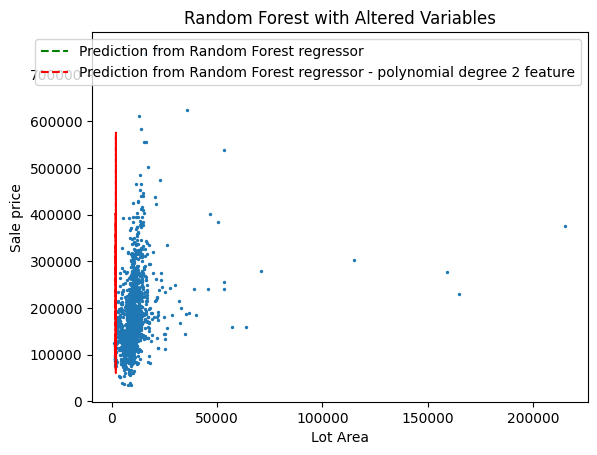

In [50]:
from sklearn import neural_network
polynomial_features = PolynomialFeatures(degree = 2)

areas = house_data_clean["LOTAREA"].values.reshape(-1,1)
sale_price = house_data_clean["SALEPRICE"].values

areas_poly = polynomial_features.fit_transform(areas)

poly_model = ensemble.RandomForestRegressor().fit(areas_poly, sale_price)
predicted_poly = poly_model.predict(areas_poly)

plt.scatter(house_data_clean["LOTAREA"], house_data_clean["SALEPRICE"], s = 2)
plt.xlabel("Lot Area")
plt.ylabel("Sale price")

plt.title("Random Forest with Altered Variables")
plt.plot(years.reshape(-1,1), predicted_price, color = 'g', ls = '--', label = "Prediction from Random Forest regressor")
plt.plot(years.reshape(-1,1), predicted_poly, color = 'r', ls = '--', label = "Prediction from Random Forest regressor - polynomial degree 2 feature")
plt.legend()
plt.savefig("RFv2.pdf")